# Research Notebook
## Altan Günes
## Date: 23.01.2026

# 1: Experience
## Describe at least one research activity you worked on this week. 

A function was written to plot galaxy rotation curves and the corresponding Jeans profiles, with free parameters that can be adjusted for later analysis.

In addition, the SPARC data set was studied to become familiar with its structure and usage.

## Motivation

The goal was to ensure that generating plots for individual data files is fast and efficient, allowing quick comparisons between different galaxies without repeatedly plotting each case manually. To achieve this, the SPARC rotation curve data set (rotmod) is used. In this data set, the different velocity components are provided as functions of radius, and the baryonic rotation velocity is computed using the prescription given in the SPARC master paper [1].

This serves as a preparation for simulating different modifications of key parameters, such as variations in the mass-to-light (luminosity) relations.



In [ ]:
def plot_rotation_curve_from_file(path_name, SMTLdisk, SMTLbulge): # Rotation curves without the jeans profile
    # file extraction
    filename = path + path_name
    df, units, dist = get_data(filename)

    # bBaryon component
    Vbaryon = np.sqrt(SMTLdisk * df['Vdisk'] * np.abs(df['Vdisk']) + SMTLbulge * df['Vbul']* np.abs(df['Vbul']) + df['Vgas']* np.abs(df['Vgas']))

    # Halo
    Vhalo = np.sqrt(np.abs(df['Vobs']**2 - Vbaryon**2)) 

    # Plot
    plt.figure(figsize=(8, 6))
    plt.errorbar(df['Rad'], df['Vobs'], yerr=df['errV'], fmt='o', label='Observed', color='black')

    plt.plot(df['Rad'], df['Vdisk'], label='Disk')
    plt.plot(df['Rad'], df['Vgas'], label='Gas')
    plt.plot(df['Rad'], df['Vbul'], label='Bulge')
    plt.plot(df['Rad'], Vbaryon, label='Baryonic Total', linestyle='--')
    plt.plot(df['Rad'], Vhalo, label='Halo', linestyle='--', color='grey')

    plt.xlabel(f"Radius ({units.at[0, 'Rad']})")
    plt.ylabel(f"Velocity ({units.at[0, 'Vobs']})")

    
    #  Name extractor
    galaxy_name = path_name.replace("_rotmod.dat", "")
    
    plt.title(f"Rotation Curve {galaxy_name} ({dist} Mpc)")
    plt.legend()
    plt.grid()
    plt.show()

    return

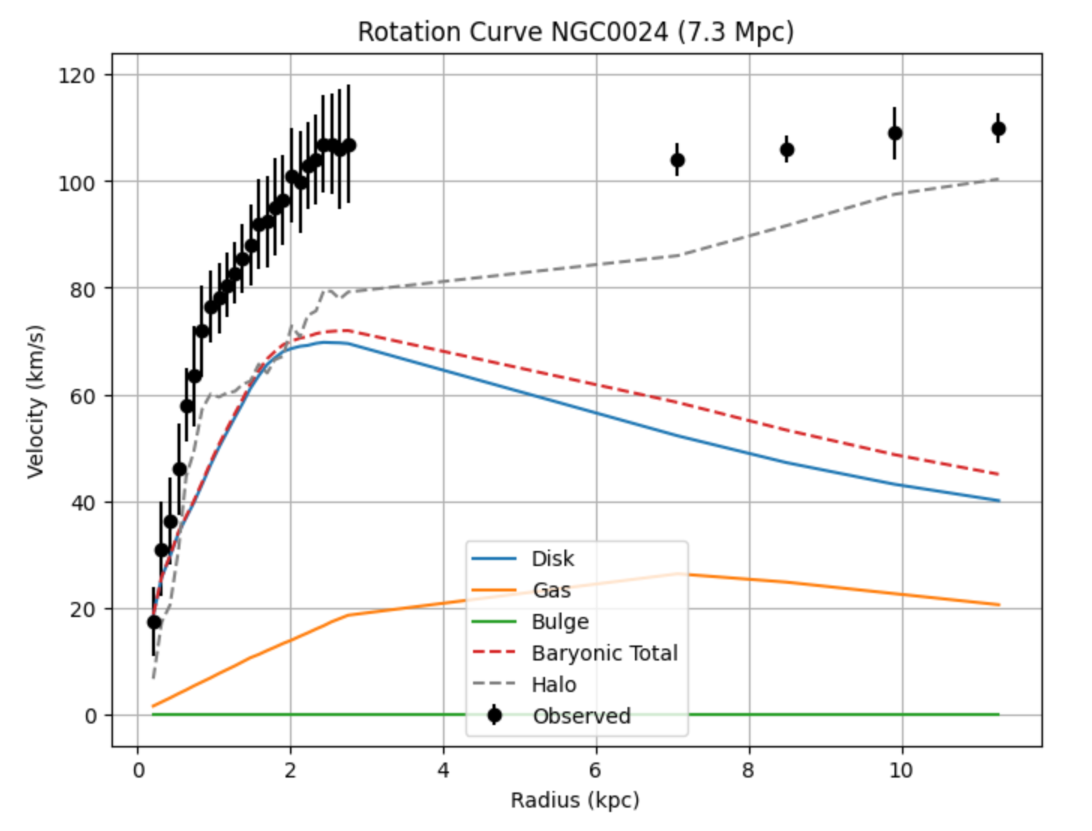

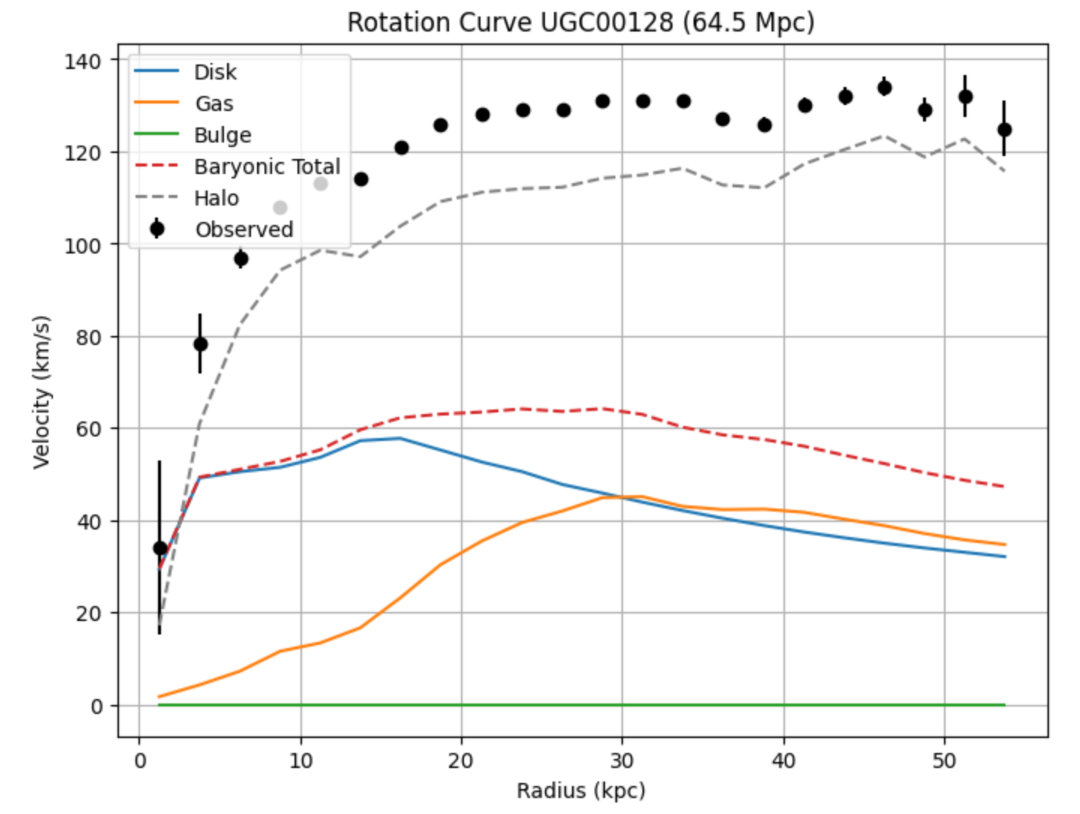

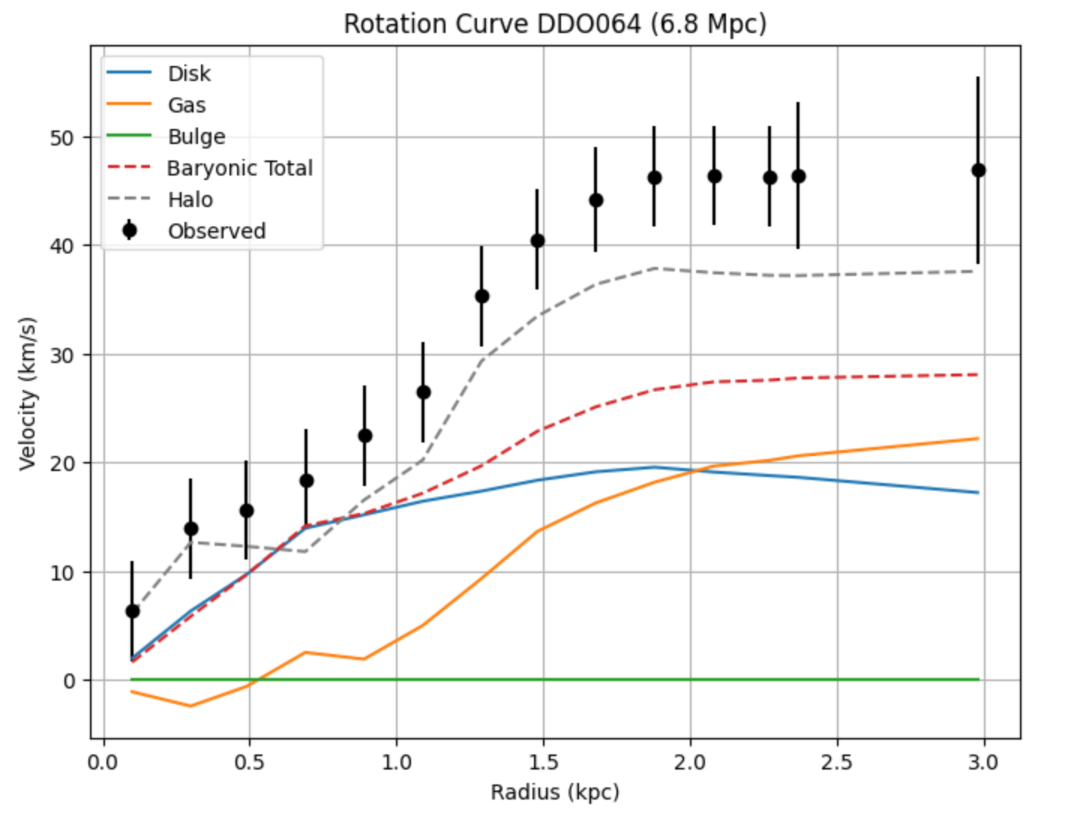

In [8]:
from IPython.display import Image, display

display(Image(filename="ScreenPics/1/Screen1.png", embed=True))
display(Image(filename="ScreenPics/1/Screen2.png", embed=True))
display(Image(filename="ScreenPics/1/Screen3.png", embed=True))


In [ ]:
def plot_rotation_curve_jeans(path_name, M200, c, Phi_b=None, Lmax=0):  # RC with jeans profile


    filename = path + path_name
    df, units, dist = get_data(filename)

    # name
    galaxy_name = os.path.basename(filename).replace("_rotmod.dat", "")

    # Jeans
    profile = jeans.squashed(dist, M200, c, Phi_b=Phi_b, verbose=True)

    # Plt
    plt.figure(figsize=(6, 4))
    plt.errorbar(
        df['Rad'], df['Vobs'], yerr=df['errV'],
        fmt='o', label='Observed', color='black', markersize=5
    )

    plt.plot(
        df['Rad'], profile.V(df['Rad'], Lmax=Lmax),
        label='Jeans Model', color='C0'
    )

    plt.xlabel(f"Radius ({units.at[0, 'Rad']})")
    plt.ylabel(f"Velocity ({units.at[0, 'Vobs']})")
    plt.title(f"Rotation Curve for {galaxy_name} (Distance: {dist} Mpc)")
    plt.legend()
    plt.grid()
    plt.show()

    return

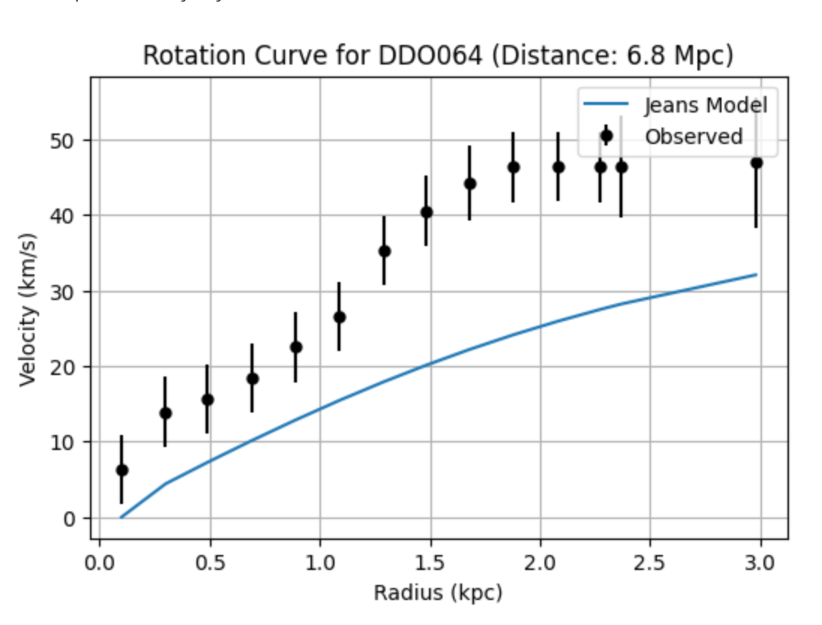

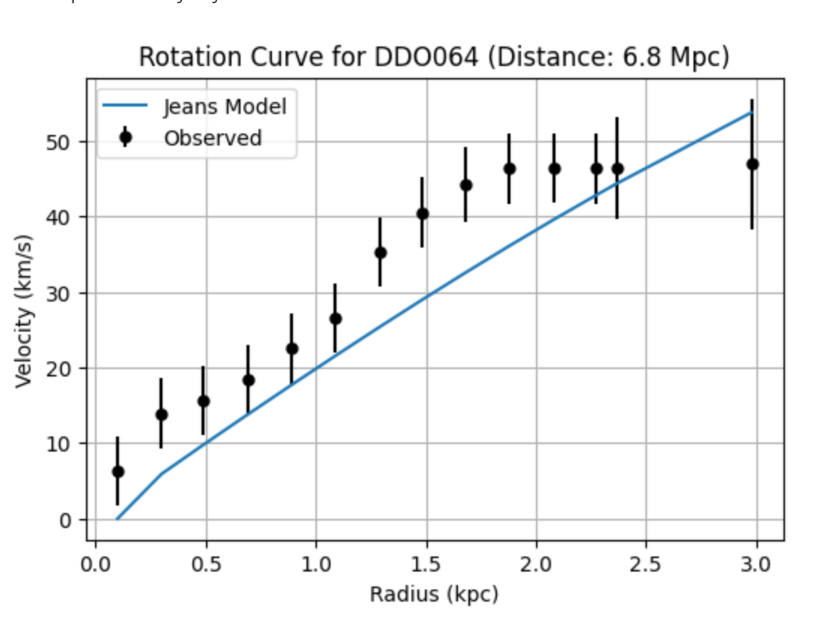

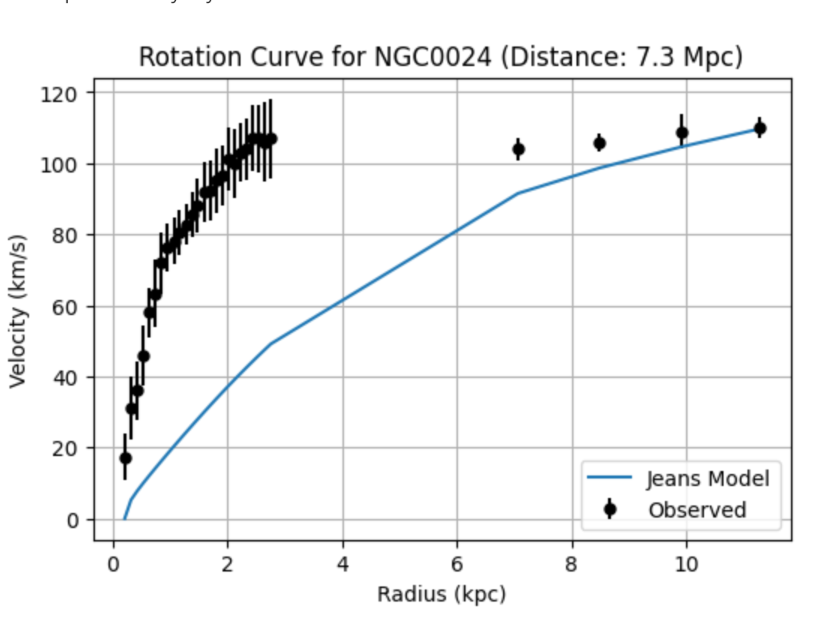

In [7]:
display(Image(filename="ScreenPics/1/Jeans.png", embed=True))
display(Image(filename="ScreenPics/1/Jeans1.png", embed=True)) # same Rotationkurve diffrent M and c
display(Image(filename="ScreenPics/1/Jeans2.png", embed=True))

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

After plotting multiple data files, some of the results behaved as expected, while others did not. This prompted a closer inspection of the equations used in the analysis. Initially, the formulation from the Getting Started notebook was applied. However, the SPARC master paper [1] uses a modified version of this formula. Adopting the formulation from the paper required changes to the code and resolved the observed discrepancies.

# 3: So what? (What does it mean?)
## Describe your results

The problem was that in the data, $v_{gas}$ contains negative components, which need to be taken into account (the first formula I used did not do this). The new equation from [1] addresses this.
$ [V_{\mathrm{bar}}(r)
=
\sqrt{
\lvert V_{\mathrm{gas}} \rvert\, V_{\mathrm{gas}}
+
\Upsilon_{\mathrm{disk}} \, \lvert V_{\mathrm{disk}} \rvert\, V_{\mathrm{disk}}
+
\Upsilon_{\mathrm{bul}} \, \lvert V_{\mathrm{bul}} \rvert\, V_{\mathrm{bul}}
}
]$

From the Jeans variable deviation, it can be seen that for higher c values, the curve approaches the profile. It is expected, however, that in this state the profile is not a reliable description, since the exact values of the baryonic potential are missing.

# 4. Now what? (What's next?)
## Plan for the next week

Using the equations from the SPARC master paper, the plot should be corrected and then tested in a comparison with my partner, as he uses a different procedure to generate these curves. From there, various open parameters in the Jeans code, such as 
$M_{200}$, c, or the light ratios, can be adjusted. If this process works smoothly, the next step will be transitioning to MCMC for these tests, allowing the variables to be explored not only manually but also over a simulated range.

# 5. Bibliography

[1] Federico Lelli, Stacy S. McGaugh1 and James M. Schombert: SPARC: MASS MODELS FOR 175 DISK GALAXIES WITH
SPITZER PHOTOMETRY AND ACCURATE ROTATION CURVES.

An LLM was used to improve the readability and clarity of the text in English.

| Category       | Points      |
| ------------- |:------------:|
| Formatting    |       2 / 2       |
| Experience    |       1 / 2       |
| What?         |       2 / 2       |
| So what?      |       4 / 4       |
| Now what?     |       4 / 4       |
| Bibliography  |       3 / 3     |
| Style         |       3 / 3       |
| Total         |       19 / 20   |